In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from transformers import AutoProcessor, AutoModel
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
from typing import List, Tuple, Optional
from PIL import Image
import torch
import os
import time
from pathlib import Path
from torchvision import transforms

import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

print(f'CUDA доступна: {torch.cuda.is_available()}')
print(f'Устройство: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

CUDA доступна: False
Устройство: CPU


In [3]:

IMAGES_DIR = Path('/content/drive/MyDrive/phillips_lot_images')

df_phillips = pd.read_csv('/content/drive/MyDrive/phillips_cleaned.csv')
df_phillips = df_phillips.dropna(subset=['image_url', 'price_usd_2026', 'year', 'month']).copy()
df_phillips = df_phillips.drop_duplicates(subset=['lot_url']).reset_index(drop=True)

def build_local_path(row) -> str:
    lot_id = str(row['lot_url']).rstrip('/').split('/')[-1]
    ext = os.path.splitext(row['image_url'])[-1]
    if not ext or len(ext) > 5:
        ext = '.jpg'
    return str(IMAGES_DIR / f'{lot_id}{ext}')

df_phillips['local_image_path'] = df_phillips.apply(build_local_path, axis=1)

# оставляем только лоты с картинками на диске
df_phillips = df_phillips[df_phillips['local_image_path'].apply(os.path.exists)].copy().reset_index(drop=True)

print(f'Размерность датасета: {df_phillips.shape}')
print(f'Картинок на диске: {df_phillips["local_image_path"].apply(os.path.exists).sum()}')

Размерность датасета: (24572, 24)
Картинок на диске: 24572


In [4]:
class AuctionsImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, image_path_col: str = 'local_image_path',
                 title_col: str = 'title', transform=None):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.image_path_col = image_path_col
        self.title_col = title_col
        self.transform = transform if transform is not None else transforms.ToTensor()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx) -> Tuple[torch.Tensor, str, str]:
        row = self.df.iloc[idx]
        image_full_path = row[self.image_path_col]
        title = row[self.title_col]

        for i in range(3):
            try:
                image = Image.open(image_full_path).convert("RGB")
                image = self.transform(image)
                return image, title, image_full_path
            except Exception as error:
                print(f"Попытка {i + 1} не удалась для {image_full_path}: {error}")
                if i == 2:
                    raise RuntimeError(f'Не удалось загрузить: {image_full_path}')
                time.sleep(0.5)


def collate_fn(batch):
    valid_batch = [b for b in batch if b is not None]
    if not valid_batch:
        return [], [], []
    images, titles, paths = zip(*valid_batch)
    return list(images), list(titles), list(paths)

In [5]:
class SigLIPEmbedding:
    def __init__(
        self,
        model_name: str = "google/siglip-base-patch16-224",
        device: Optional[str] = None,
    ) -> None:
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        print(f'Используется устройство: {self.device}')
        self.model = AutoModel.from_pretrained(model_name).to(self.device)
        self.processor = AutoProcessor.from_pretrained(model_name)
        self.model.eval()
        self.transform = transforms.Compose([transforms.ToTensor()])

    @torch.no_grad()
    def _get_embedding_(
        self,
        df: pd.DataFrame,
        batch_size: int = 32,
        shuffle: bool = False,
        norm_l2: bool = True,
        save_dir: str = '/content/drive/MyDrive/phillips_embeddings_cache',
        save_every: int = 50
    ) -> Tuple[np.ndarray, List[str], List[str]]:

        save_path = Path(save_dir)
        save_path.mkdir(exist_ok=True, parents=True)

        # нумерация чанков продолжается с того места где остановились
        existing_chunks = sorted(save_path.glob('chunk_emb_*.npy'))
        chunk_idx = len(existing_chunks)
        print(f'Начинаем сохранение с chunk_emb_{chunk_idx:04d}.npy')

        images_dataset = AuctionsImageDataset(df, transform=self.transform)
        print(f"Всего {len(images_dataset)} картин")

        images_dataloader = DataLoader(
            dataset=images_dataset,
            shuffle=shuffle,
            batch_size=batch_size,
            pin_memory=False,
            collate_fn=collate_fn,
            drop_last=False
        )

        batch_embeddings = []
        batch_titles = []
        batch_paths = []

        for b_images, b_titles, b_paths in tqdm(images_dataloader, desc="Обработка картин"):
            if b_images is None or len(b_images) == 0:
                continue

            images_preprocessed = self.processor(
                images=b_images,
                return_tensors='pt',
                padding=True,
                do_rescale=False
            ).to(self.device)

            output = self.model.vision_model(**images_preprocessed)
            images_embeddings = output.pooler_output

            if norm_l2:
                images_embeddings = images_embeddings / images_embeddings.norm(p=2, dim=-1, keepdim=True)

            batch_embeddings.append(images_embeddings.cpu().numpy())
            batch_titles.extend(b_titles)
            batch_paths.extend(b_paths)

            if len(batch_embeddings) >= save_every:
                chunk_emb = np.vstack(batch_embeddings)
                np.save(save_path / f'chunk_emb_{chunk_idx:04d}.npy', chunk_emb)
                np.save(save_path / f'chunk_titles_{chunk_idx:04d}.npy',
                        np.array(batch_titles, dtype=object))
                np.save(save_path / f'chunk_paths_{chunk_idx:04d}.npy',
                        np.array(batch_paths, dtype=object))
                print(f'Сохранён чанк {chunk_idx} ({chunk_emb.shape[0]} эмбеддингов)')
                chunk_idx += 1
                batch_embeddings = []
                batch_titles = []
                batch_paths = []
                torch.cuda.empty_cache()

        # последний неполный чанк
        if batch_embeddings:
            chunk_emb = np.vstack(batch_embeddings)
            np.save(save_path / f'chunk_emb_{chunk_idx:04d}.npy', chunk_emb)
            np.save(save_path / f'chunk_titles_{chunk_idx:04d}.npy',
                    np.array(batch_titles, dtype=object))
            np.save(save_path / f'chunk_paths_{chunk_idx:04d}.npy',
                    np.array(batch_paths, dtype=object))
            print(f'Сохранён финальный чанк {chunk_idx} ({chunk_emb.shape[0]} эмбеддингов)')

        # склеиваем все чанки
        print('Склейка чанков...')
        all_emb_chunks = sorted(save_path.glob('chunk_emb_*.npy'))
        all_title_chunks = sorted(save_path.glob('chunk_titles_*.npy'))
        all_path_chunks = sorted(save_path.glob('chunk_paths_*.npy'))

        embeddings = np.vstack([np.load(f) for f in all_emb_chunks])
        all_titles = np.concatenate([np.load(f, allow_pickle=True)
                                     for f in all_title_chunks]).tolist()
        all_paths = np.concatenate([np.load(f, allow_pickle=True)
                                    for f in all_path_chunks]).tolist()

        print(f'Итоговая размерность эмбеддингов: {embeddings.shape}')
        print(f'Titles: {len(all_titles)}, Paths: {len(all_paths)}')

        return embeddings, all_titles, all_paths

In [7]:
save_path = Path('/content/drive/MyDrive/phillips_embeddings_cache')

start_idx = sum(np.load(f).shape[0] for f in sorted(save_path.glob('chunk_emb_*.npy')))
chunk_idx = len(list(save_path.glob('chunk_emb_*.npy')))

print(f'Всего чанков: {chunk_idx}')
print(f'Продолжаем с картинки: {start_idx}')

df_remaining = df_phillips.iloc[start_idx:].reset_index(drop=True)
print(f'Осталось обработать: {len(df_remaining)} картинок')

siglip_encoder = SigLIPEmbedding()

embeddings, all_titles, all_paths = siglip_encoder._get_embedding_(
    df=df_remaining,
    batch_size=16,
    shuffle=False,
    norm_l2=True
)

print(f'Готово. Размерность эмбеддингов: {embeddings.shape}')

Всего чанков: 18
Продолжаем с картинки: 17600
Осталось обработать: 6972 картинок
Используется устройство: cpu


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

Начинаем сохранение с chunk_emb_0018.npy
Всего 6972 картин


Обработка картин:   0%|          | 0/436 [00:00<?, ?it/s]

Сохранён чанк 18 (800 эмбеддингов)
Сохранён чанк 19 (800 эмбеддингов)
Сохранён чанк 20 (800 эмбеддингов)
Сохранён чанк 21 (800 эмбеддингов)
Сохранён чанк 22 (800 эмбеддингов)
Сохранён чанк 23 (800 эмбеддингов)
Сохранён чанк 24 (800 эмбеддингов)
Сохранён чанк 25 (800 эмбеддингов)
Сохранён финальный чанк 26 (572 эмбеддингов)
Склейка чанков...
Итоговая размерность эмбеддингов: (24572, 768)
Titles: 18172, Paths: 18172
Готово. Размерность эмбеддингов: (24572, 768)


In [ ]:
save_path = Path('/content/drive/MyDrive/phillips_embeddings_cache')

start_idx = sum(np.load(f).shape[0] for f in sorted(save_path.glob('chunk_emb_*.npy')))
chunk_idx = len(list(save_path.glob('chunk_emb_*.npy')))

print(f'Всего чанков: {chunk_idx}')
print(f'Продолжаем с картинки: {start_idx}')

Всего чанков: 10
Продолжаем с картинки: 11200


In [6]:
save_path = Path('/content/drive/MyDrive/phillips_embeddings_cache')
start_idx = sum(np.load(f).shape[0] for f in sorted(save_path.glob('chunk_emb_*.npy')))
print(f'Обработано: {start_idx}')
print(f'Осталось: {24572 - start_idx}')

Обработано: 17600
Осталось: 6972


In [8]:
save_path = Path('/content/drive/MyDrive/phillips_embeddings_cache')

all_embeddings = np.vstack([
    np.load(f) for f in sorted(save_path.glob('chunk_emb_*.npy'))
])

print(f'Финальная размерность: {all_embeddings.shape}')

np.save('/content/drive/MyDrive/phillips_embeddings_final.npy', all_embeddings)
print('Сохранено: phillips_embeddings_final.npy')

Финальная размерность: (24572, 768)
Сохранено: phillips_embeddings_final.npy


In [9]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

embeddings = np.load('/content/drive/MyDrive/phillips_embeddings_final.npy')

print(f'Эмбеддингов: {embeddings.shape[0]}')
print(f'Строк в df: {len(df_phillips)}')
print(f'Совпадают: {embeddings.shape[0] == len(df_phillips)}')

Эмбеддингов: 24572
Строк в df: 24572
Совпадают: True


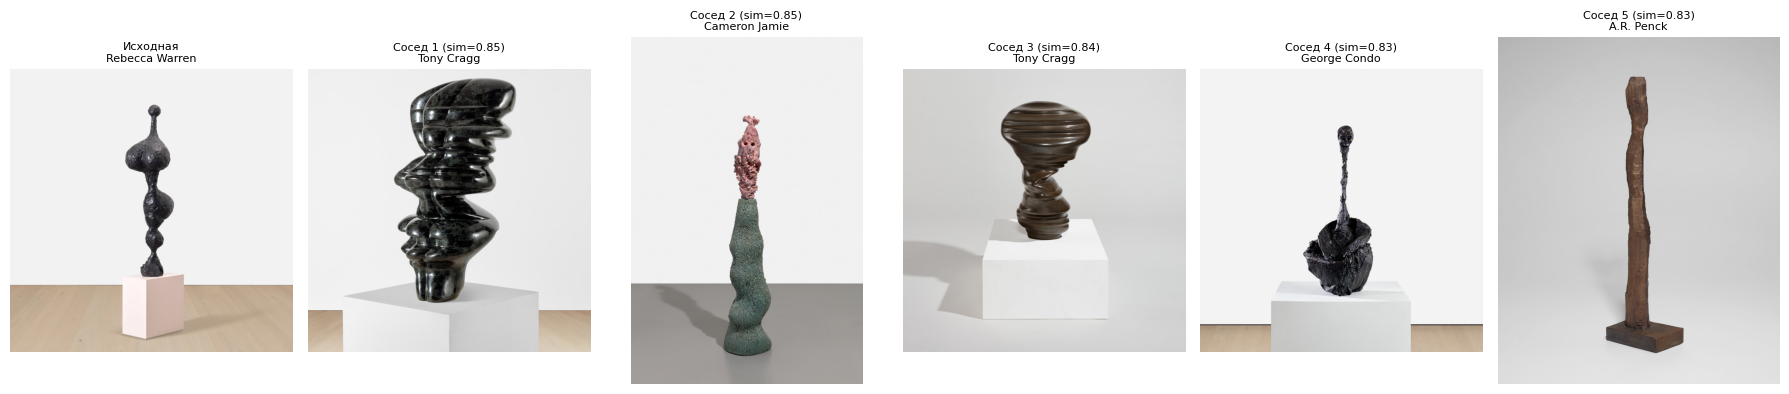

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

# берём случайный индекс
idx = 100

# находим 5 ближайших соседей по эмбеддингу
sims = cosine_similarity(embeddings[idx:idx+1], embeddings)[0]
top5_idx = np.argsort(sims)[::-1][1:6]  # исключаем саму картинку

# показываем исходную картинку и её соседей
fig, axes = plt.subplots(1, 6, figsize=(18, 4))

# исходная
img = Image.open(df_phillips.iloc[idx]['local_image_path']).convert('RGB')
axes[0].imshow(img)
axes[0].set_title(f'Исходная\n{df_phillips.iloc[idx]["artist"][:20]}', fontsize=8)
axes[0].axis('off')

# соседи
for i, neighbor_idx in enumerate(top5_idx):
    img = Image.open(df_phillips.iloc[neighbor_idx]['local_image_path']).convert('RGB')
    axes[i+1].imshow(img)
    axes[i+1].set_title(f'Сосед {i+1} (sim={sims[neighbor_idx]:.2f})\n{df_phillips.iloc[neighbor_idx]["artist"][:20]}', fontsize=8)
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()